### Téléchargement et Split des dossiers (Phase 1.1)

In [8]:
import os, shutil, random
from PIL import Image

# 1. Configuration
DATA_ROOT = "/kaggle/working/data"
BASE_DIR = "/kaggle/input/datasets/zlatan599/fruitquality1/Unified_Dataset"

# 2. Nettoyage complet avant de commencer
if os.path.exists(DATA_ROOT):
    shutil.rmtree(DATA_ROOT)
os.makedirs(DATA_ROOT, exist_ok=True)

print("🔍 Analyse et copie des images valides...")
classes_generees = []

if os.path.exists(BASE_DIR):
    fruits = [f for f in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, f))]
    
    for fruit in fruits:
        fruit_dir = os.path.join(BASE_DIR, fruit)
        etats = [e for e in os.listdir(fruit_dir) if os.path.isdir(os.path.join(fruit_dir, e))]
        
        for etat in etats:
            class_name = f"{fruit.lower()}_{etat.lower()}"
            classes_generees.append(class_name)
            
            os.makedirs(os.path.join(DATA_ROOT, 'train', class_name), exist_ok=True)
            os.makedirs(os.path.join(DATA_ROOT, 'val', class_name), exist_ok=True)
            
            etat_dir = os.path.join(fruit_dir, etat)
            all_files = [os.path.join(etat_dir, f) for f in os.listdir(etat_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            # --- FILTRE D'INTÉGRITÉ ---
            # On ne garde que les fichiers que PIL arrive à ouvrir réellement
            images_valides = []
            for f in all_files:
                try:
                    with Image.open(f) as img:
                        img.verify() # Vérifie que le fichier n'est pas corrompu
                    images_valides.append(f)
                except:
                    # Si le fichier est illisible, on l'ignore silencieusement
                    continue
            
            random.seed(42)
            random.shuffle(images_valides)
            
            # Split 80/20
            idx = int(len(images_valides) * 0.8)
            for img in images_valides[:idx]: 
                shutil.copy(img, os.path.join(DATA_ROOT, 'train', class_name))
            for img in images_valides[idx:]: 
                shutil.copy(img, os.path.join(DATA_ROOT, 'val', class_name))

print(f"✅ {len(classes_generees)} classes créées.")
print("=== BILAN DU SPLIT SÉCURISÉ ===")
for split in ['train', 'val']:
    count = sum([len(os.listdir(os.path.join(DATA_ROOT, split, c))) for c in classes_generees])
    print(f"Total {split} : {count} images valides.")

🔍 Analyse et copie des images valides...
✅ 28 classes créées.
=== BILAN DU SPLIT SÉCURISÉ ===
Total train : 23414 images valides.
Total val : 5863 images valides.


In [14]:
import os
import tensorflow as tf

data_dir = "/kaggle/working/data"
print("🧹 Nettoyage définitif avec le moteur de TensorFlow...")

fichiers_supprimes = 0
for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            # On force TensorFlow à lire TOUT le fichier (ce que PIL ne faisait pas)
            img_bytes = tf.io.read_file(file_path)
            _ = tf.image.decode_image(img_bytes, expand_animations=False)
        except Exception:
            print(f"🗑️ Fichier illisible supprimé : {file_path}")
            os.remove(file_path)
            fichiers_supprimes += 1

print(f"✅ Terminé ! {fichiers_supprimes} fichiers corrompus ont été trouvés et supprimés.")

🧹 Nettoyage définitif avec le moteur de TensorFlow...
🗑️ Fichier illisible supprimé : /kaggle/working/data/train/bellpepper_rotten/rottenPepper (1).jpg
🗑️ Fichier illisible supprimé : /kaggle/working/data/train/banana_fresh/freshBanana (422).jpg
🗑️ Fichier illisible supprimé : /kaggle/working/data/train/carrot_fresh/freshCarrot (415).jpg
✅ Terminé ! 3 fichiers corrompus ont été trouvés et supprimés.


### Affichage d'un échantillon aléatoire

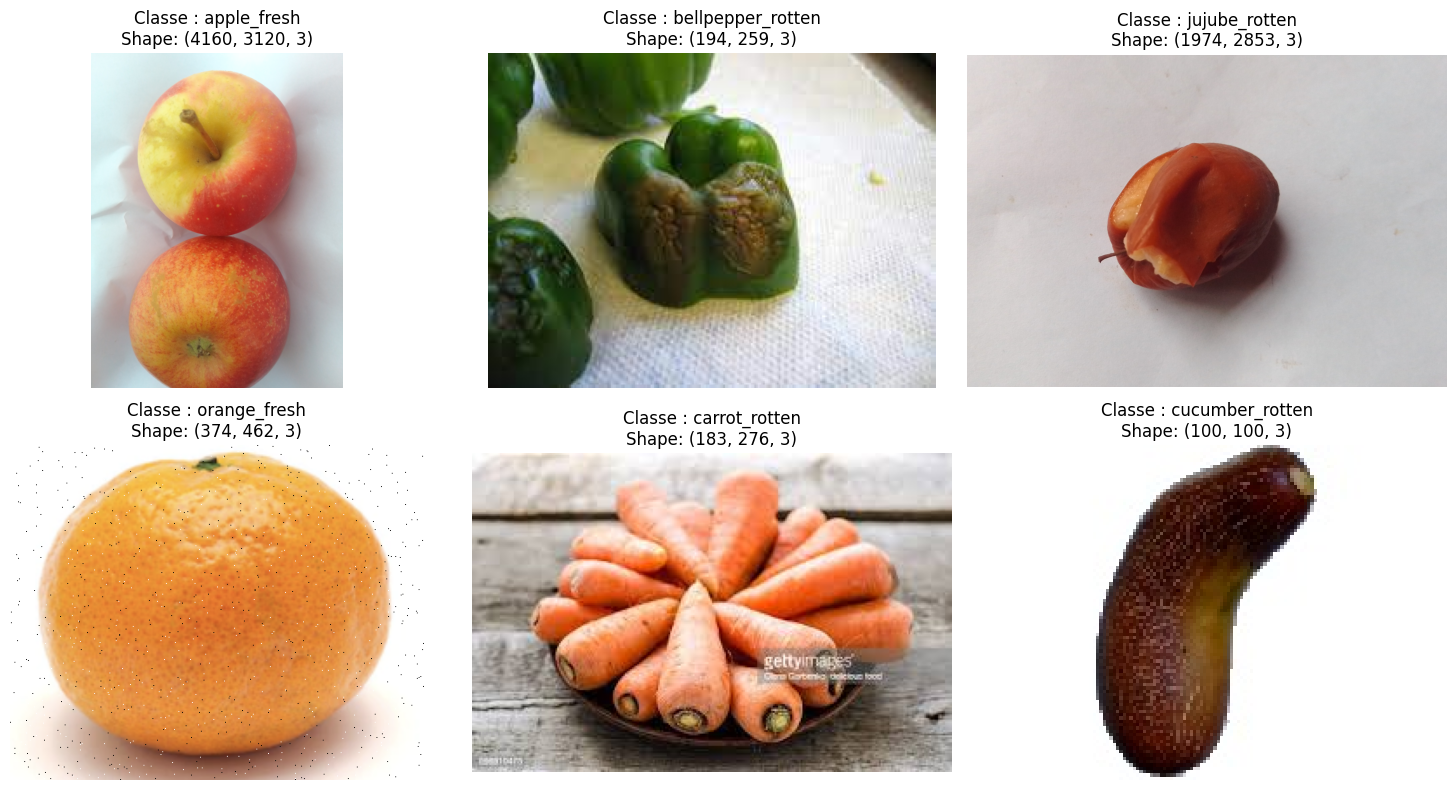

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(15, 8))
train_dir = os.path.join(DATA_ROOT, 'train')

# Récupérer 6 classes au hasard pour l'affichage
classes = random.sample(os.listdir(train_dir), 6)

for i, cls in enumerate(classes):
    cls_dir = os.path.join(train_dir, cls)
    images = os.listdir(cls_dir)
    if images: # Vérifie que le dossier n'est pas vide
        img_path = os.path.join(cls_dir, images[0]) # Prend la 1ère image
        img = mpimg.imread(img_path)
        
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Classe : {cls}\nShape: {img.shape}")
        plt.axis('off')

plt.tight_layout()
plt.show()

### Data Loaders

In [16]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print("➡️ Chargement du dataset d'entraînement (Multi-classes) :")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # <--- CRUCIAL POUR LE MULTI-CLASSES
)

print("\n➡️ Chargement du dataset de validation :")
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # <--- CRUCIAL
)

# On sauvegarde la liste des noms de classes exactes pour l'inférence plus tard
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

# Optimisation en RAM
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"\n✅ Data Loaders prêts ! Le CNN devra prédire parmi {NUM_CLASSES} classes différentes.")

➡️ Chargement du dataset d'entraînement (Multi-classes) :
Found 23411 files belonging to 28 classes.

➡️ Chargement du dataset de validation :
Found 5863 files belonging to 28 classes.

✅ Data Loaders prêts ! Le CNN devra prédire parmi 28 classes différentes.


### Preprocessing, Normalisation et Batching

In [17]:
import tensorflow as tf
import numpy as np

# === 1. CONFIGURATION ===
# 128x128 est un excellent
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Optionnel mais recommandé : Nettoyer les dossiers parasites (ex: .ipynb_checkpoints)
# pour éviter l'erreur "Adversarial"
!find {DATA_ROOT} -name ".ipynb_checkpoints" -type d -exec rm -rf {} +

# === 2. CRÉATION DES DATASETS (MULTI-CLASSES) ===
print("➡️ Configuration de train_ds...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical', # Mode multi-classes !
    shuffle=True,
    seed=42
)

print("\n➡️ Configuration de val_ds...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical', 
    shuffle=False # Pour garder une évaluation constante
)

# === 3. NORMALISATION (Rescaling) ===
# Le CNN converge beaucoup mieux si les pixels sont entre 0 et 1 (au lieu de 0 et 255)
normalization_layer = tf.keras.layers.Rescaling(1./255)

# On applique la normalisation à la volée avec .map()
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# === 4. OPTIMISATION DES PERFORMANCES (Le "Happy Path") ===
AUTOTUNE = tf.data.AUTOTUNE
# Cache : charge en RAM après la 1ère lecture. Prefetch : prépare le batch N+1 pendant que le GPU calcule le batch N.
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# === 5. VÉRIFICATION DU PREMIER BATCH ===
print("\n=== VÉRIFICATION DU PREMIER BATCH ===")
# next(iter()) simule ce que le réseau de neurones va "aspirer" à la première itération
image_batch, label_batch = next(iter(train_ds))

print(f"Shape images batch : {image_batch.shape}")
print(f"Shape labels batch : {label_batch.shape}") # Attendu : (32, nombre_de_classes)
print(f"Valeurs pixels     : min = {np.min(image_batch):.2f}, max = {np.max(image_batch):.2f}")

if 0.0 <= np.min(image_batch) and np.max(image_batch) <= 1.0:
    print("✅ Normalisation réussie (valeurs entre 0.0 et 1.0) !")
else:
    print("❌ Problème de normalisation.")

find: ‘{DATA_ROOT}’: No such file or directory
➡️ Configuration de train_ds...
Found 23411 files belonging to 28 classes.

➡️ Configuration de val_ds...
Found 5863 files belonging to 28 classes.

=== VÉRIFICATION DU PREMIER BATCH ===
Shape images batch : (32, 128, 128, 3)
Shape labels batch : (32, 28)
Valeurs pixels     : min = 0.00, max = 1.00
✅ Normalisation réussie (valeurs entre 0.0 et 1.0) !


### Architecture CNN (Adaptée Multi-classes)

In [18]:
from tensorflow.keras import layers, models

def build_cnn_scratch(input_shape, num_classes):
    """
    CNN from scratch pour la classification MULTI-CLASSES.
    Architecture simple pour observer l'overfitting initial.
    """
    model = models.Sequential([
        # --- Bloc 1 ---
        # Padding='same' conserve la taille spatiale après la convolution
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)), # Shape sortie : (64, 64, 32)
        
        # --- Bloc 2 ---
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)), # Shape sortie : (32, 32, 64)
        
        # --- Bloc 3 ---
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)), # Shape sortie : (16, 16, 128)
        
        # --- Transition vers les couches denses ---
        layers.Flatten(),           # Shape sortie : (32768,)
        
        layers.Dense(128, activation='relu'),
        
        # --- Couche de sortie MULTI-CLASSES ---
        # Remplacement de 'sigmoid' (binaire) par 'softmax' (proba par classe)
        # On utilise NUM_CLASSES (ex: 14) au lieu de 1 neurone
        layers.Dense(num_classes, activation='softmax') 
    ])
    return model

# Création du modèle
model_scratch = build_cnn_scratch(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), 
    num_classes=NUM_CLASSES
)

# Affichage de l'architecture pour vérifier nos calculs (Quality Gate)
print("\n=== ARCHITECTURE DU MODÈLE ===")
model_scratch.summary()

# Compilation adaptée au Multi-classes
model_scratch.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # <-- Très important en multi-classes !
    metrics=['accuracy']
)

print("\n✅ Modèle compilé avec succès ! Prêt pour l'entraînement.")    


=== ARCHITECTURE DU MODÈLE ===


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,291,292 (16.37 MB)

 Trainable params: 4,291,292 (16.37 MB)

 Non-trainable params: 0 (0.00 B)


✅ Modèle compilé avec succès ! Prêt pour l'entraînement.


### Entraînement et Diagnostic de l'Overfitting

🚀 Lancement de l'entraînement sur 20 epochs maximum...
Epoch 1/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 65s 84ms/step - accuracy: 0.4418 - loss: 1.9085 - val_accuracy: 0.7633 - val_loss: 0.7770
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8000 - loss: 0.6561 - val_accuracy: 0.8248 - val_loss: 0.6053
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8844 - loss: 0.3706 - val_accuracy: 0.8405 - val_loss: 0.6173
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9226 - loss: 0.2364 - val_accuracy: 0.8564 - val_loss: 0.5772
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9497 - loss: 0.1546 - val_accuracy: 0.8596 - val_loss: 0.6461
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9635 - loss: 0.1155 - val_accuracy: 0.8714 - val_loss: 0.6474
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9713 - loss: 0.0910 - val_accuracy: 0.8412 - val_loss: 0.7894
Epoch 8/20
732/732 ━━━━━━━━━━━━━━━━

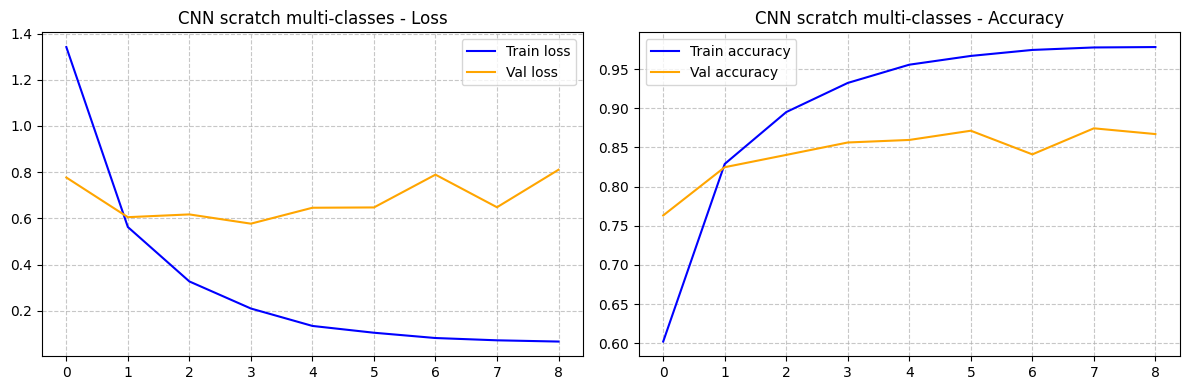

In [19]:
import datetime, time
import tensorflow as tf
import matplotlib.pyplot as plt

# === 1. CALLBACKS (TensorBoard & EarlyStopping) ===
# TensorBoard pour visualiser l'entraînement en direct
log_dir = "logs/scratch/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# EarlyStopping : On arrête l'hémorragie si la val_loss remonte pendant 5 epochs de suite.
# restore_best_weights=True est crucial : il annule les epochs d'overfitting et garde les meilleurs poids.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# === 2. ENTRAÎNEMENT ===
EPOCHS = 20
print(f"🚀 Lancement de l'entraînement sur {EPOCHS} epochs maximum...")
start = time.time()

history_scratch = model_scratch.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[tensorboard_callback, early_stopping]
)

training_time_scratch = time.time() - start
print(f"\n⏱️ Temps d'entraînement : {training_time_scratch:.0f}s")
print(f"🎯 val_accuracy finale (optimale) : {max(history_scratch.history['val_accuracy']):.3f}")

# === 3. SAUVEGARDE DU LIVRABLE TP1 ===
model_scratch.save('/kaggle/working/model_scratch_tp1.keras')
print("💾 Meilleur modèle TP1 sauvegardé sous 'model_scratch_tp1.keras'")

# === 4. VISUALISATION DES COURBES ===
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Courbe de Loss
    ax1.plot(history.history['loss'], label='Train loss', color='blue')
    ax1.plot(history.history['val_loss'], label='Val loss', color='orange')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Courbe d'Accuracy
    ax2.plot(history.history['accuracy'], label='Train accuracy', color='blue')
    ax2.plot(history.history['val_accuracy'], label='Val accuracy', color='orange')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    # Sauvegarde de l'image pour ton repo
    plt.savefig(f"/kaggle/working/curves_{title.lower().replace(' ', '_')}.png", dpi=100)
    plt.show()

plot_history(history_scratch, "CNN scratch multi-classes")

### Intégration du Pipeline d'Augmentation

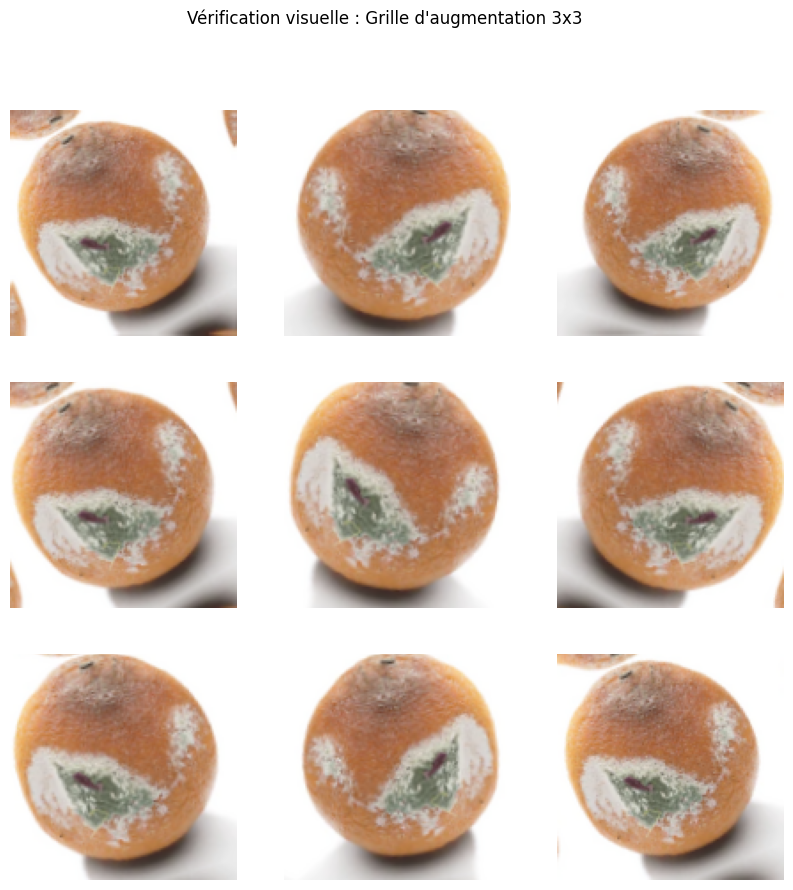

✅ Pipeline d'augmentation vérifié et grille affichée !


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Définition du pipeline d'augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),  
    layers.RandomZoom(0.1),      
], name="data_augmentation")

# 2. Récupération d'UNE SEULE image (Méthode infaillible)
# On prend le premier batch disponible, on extrait les images, 
# on sauvegarde la 1ère image (index 0), puis on stoppe.
for batch_images, batch_labels in train_ds.take(1):
    sample_image = batch_images[0]
    break

# 3. Affichage
plt.figure(figsize=(10, 10))
for i in range(9):
    # tf.expand_dims rajoute la dimension "batch" requise par Keras
    # La shape passe de (128, 128, 3) à (1, 128, 128, 3)
    augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
    
    plt.subplot(3, 3, i + 1)
    # On retire la dimension batch pour l'affichage avec
    plt.imshow(augmented[0])
    plt.axis('off')

plt.suptitle("Vérification visuelle : Grille d'augmentation 3x3")
plt.savefig("augmentation_grid.png", dpi=100)
plt.show()

print("✅ Pipeline d'augmentation vérifié et grille affichée !")

🚀 Réentraînement avec augmentation et Dropout sur 28 classes...
Epoch 1/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.4047 - loss: 2.0215 - val_accuracy: 0.7228 - val_loss: 0.9193
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7288 - loss: 0.8970 - val_accuracy: 0.7754 - val_loss: 0.7449
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7873 - loss: 0.6877 - val_accuracy: 0.8276 - val_loss: 0.5547
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8230 - loss: 0.5659 - val_accuracy: 0.8531 - val_loss: 0.5010
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8492 - loss: 0.4876 - val_accuracy: 0.8595 - val_loss: 0.4626
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8642 - loss: 0.4228 - val_accuracy: 0.8847 - val_loss: 0.3833
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8808 - loss: 0.3767 - val_accuracy: 0.8803 - val_loss: 0.4008
Epoch 8/20
732/732 ━━━━━━━

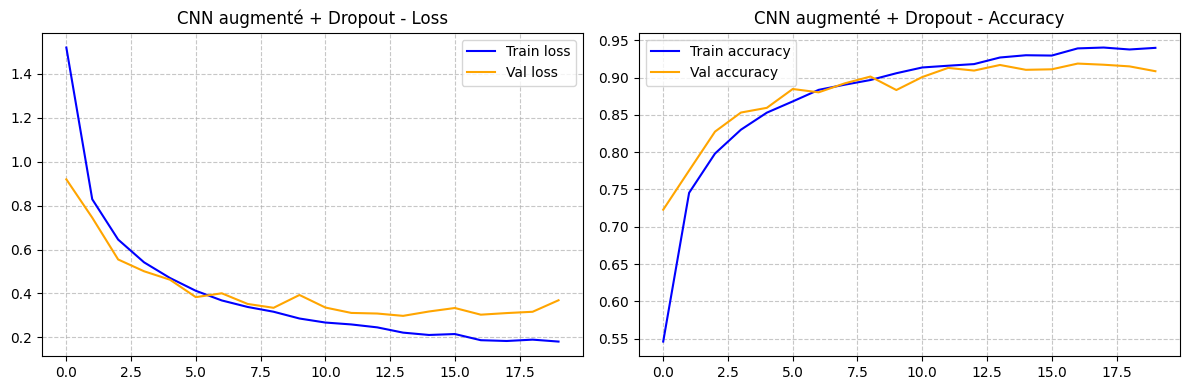

In [25]:
from tensorflow.keras import layers, models
import datetime, time

def build_cnn_augmented(input_shape, num_classes):
    """
    CNN avec data augmentation intégrée + Dropout.
    Utilise la couche data_augmentation définie en phase 2.1.
    """
    model = models.Sequential([
        # 1. Pipeline d'augmentation (actif seulement en training)
        data_augmentation,
        
        # 2. Architecture de base (Blocs Conv du TP1)
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        
        # 3. Transition et Régularisation
        layers.Flatten(),
        
        # Le Dropout se place ici : on coupe 40% des connexions avant la couche Dense
        layers.Dropout(0.4), 
        
        layers.Dense(128, activation='relu'),
        
        # 4. Sortie Multi-classes (28 neurones avec softmax)
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Création du nouveau modèle
model_augmented = build_cnn_augmented(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), 
    num_classes=NUM_CLASSES
)

# Compilation (Identique au TP1 pour comparer équitablement)
model_augmented.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Configuration des Callbacks (Logs dans /augmented/)
log_dir_aug = "logs/augmented/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_aug = tf.keras.callbacks.TensorBoard(log_dir=log_dir_aug, histogram_freq=1)

early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8, # On augmente la patience car la régularisation ralentit la convergence
    restore_best_weights=True,
    verbose=1
)

# Lancement de l'entraînement
print(f"🚀 Réentraînement avec augmentation et Dropout sur {NUM_CLASSES} classes...")
start_aug = time.time()

history_augmented = model_augmented.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[tensorboard_callback_aug, early_stopping_aug]
)

training_time_augmented = time.time() - start_aug

# Diagnostic final
print(f"\n⏱️ Temps d'entraînement : {training_time_augmented:.0f}s")
print(f"🎯 val_accuracy finale : {max(history_augmented.history['val_accuracy']):.3f}")

# Sauvegarde du livrable TP2
model_augmented.save('/kaggle/working/model_augmented_tp2.keras')

# Visualisation
plot_history(history_augmented, "CNN augmenté + Dropout")